In [ ]:
import time

start_time = time.time()
print(f"Start time recorded: {start_time}")

Start time recorded: 1764659102.9609418


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/02_finetune_with_crf_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### CryoParticleSegment

In [1]:
# @markdown package install
do = False # @param{type:"boolean"}
if do:
    %pip install torchinfo -qq
    %pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq

## ⭐ Setup
You must run all codes under this category.

In [2]:
if do:
    !git clone https://github.com/phonchi/CryoParticleSegment.git

    !wget -O /content/CryoParticleSegment/Modeling/convcrf.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
    !wget -O /content/CryoParticleSegment/Modeling/dataset.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/dataset.py
    !wget -O /content/CryoParticleSegment/Modeling/model.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/model.py
    !wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/trainer.py

In [3]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

> #### ⚠ Notice
>
> You need to restart the kernel after the compilation step. Additionally, if your GPU architecture differs, you may need to modify the file at `/content/CryoParticleSegment/Modeling/CRF_main/setup.py`. (We attempt to detect the GPU configuration automatically, so this step is usually not necessary.)
> Furthermore, depending on the number of classes and other parameters, you may encounter an error that requires adjusting the file at `/content/CryoParticleSegment/Modeling/CRF_main/src/PermutohedralFiltering/source/gpu/LatticeFilter.cu`:
>
> 1. Note the `pd` and `vd` values from the error message.
> 2. Add an `else if (pd == ? && vd == ?)` block.
> 3. Within that block, insert the following line, replacing `pd` and `vd` with the specific values:
>
>    ```cpp
>    latticeFilterGPU<pd, vd>(output_tensor, input_tensor, positions, num_super_pixels, backward);
>    ```
> 4. Recompile using `setup.py`.

In [4]:
if do:
    #!git clone https://github.com/netw0rkf10w/CRF.git
    %cd CryoParticleSegment/Modeling/CRF_main
    !python setup.py clean --all
    !rm -rf build/
    !python setup.py build_ext --inplace --force
    !python setup.py install

    crf_path = os.path.join(os.getcwd(), 'CRF')
    if crf_path not in sys.path:
        sys.path.insert(0, crf_path)

    print(f"Added {crf_path} to the Python path.")

In [5]:
%cd /content/

/content


### ✅ Directory Settings

In [6]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [7]:
# @title  { display-mode: "form" }

INPUT_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
IMAGE_DIR = INPUT_IMAGE_DIR
# @markdown ---

use_denoised_as_pariwise = False # @param {type : "boolean"}
dnzd_pw = use_denoised_as_pariwise
DENOISED_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
# @markdown ---

LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz/10017/unet_eb5_dice_CRF" # @param {type:"string"}

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# @title  { display-mode: "form" }
# @markdown Detect whether using folder in Google Drive as **`RESULT DIR`**📁.
import os
if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if not os.path.exists("/content/image_dir"):
        if "content" in IMAGE_DIR.split("/")[:3]:
            !cp -r {IMAGE_DIR} /content/image_dir
            IMAGE_DIR = "/content/image_dir"
        if "content" in LABEL_DIR.split("/")[:3]:
            !cp -r {LABEL_DIR} /content/label_dir
            LABEL_DIR = "/content/label_dir"
        if dnzd_pw == True:
            !cp -r {DENOISED_IMAGE_DIR} /content/denoised_image_dir
            DENOISED_IMAGE_DIR = "/content/denoised_image_dir"
  except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ✅ Packages Handling

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR

In [11]:
from dataset import MicrographDataset, MicrographDatasetEvery
from dataset import reconstruct_patched, collate_fn
from model import create_model
from trainer import CryoEMEvaluator
from trainer import CryoEMTrainerWithScheduler, tqdm_plugin_for_Trainer

## ⭐ Main

### ✅ Setting

In [12]:
# @markdown Parameters.

user = True # @param {type:"boolean"}

In [13]:
# @markdown Parameters.

NUM_CLASSES = 2
EPOCHS = 100
BATCH = 2
CROP_SIZE = (512, 512)
LR = 1e-3

RLR_PATIENCE = 3
ES_PATIENCE = 15
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

### ✅ Dataset

You can provide a [`transforms.CenterCrop(3840)`](https://docs.pytorch.org/vision/master/generated/torchvision.transforms.CenterCrop.html) object to crop out boundary artifacts.


In [15]:
crop = transforms.CenterCrop(3840)

In [16]:
train_dir = os.path.join(IMAGE_DIR, 'train')
train_filenames = np.loadtxt(f"{IMAGE_DIR}/train_filenames.txt", dtype=str)
if dnzd_pw == False:
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)
else:
    dnzd_train_dir = os.path.join(DENOISED_IMAGE_DIR, 'train')
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_train_dir, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)

In [17]:
val_dir = os.path.join(IMAGE_DIR, 'val')
val_filenames = np.loadtxt(f"{IMAGE_DIR}/val_filenames.txt", dtype=str)
if dnzd_pw == False:
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
else:
    dnzd_val_dir = os.path.join(DENOISED_IMAGE_DIR, 'val')
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_val_dir, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
val_loader = DataLoader(val_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [18]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    if dnzd_pw == False:
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=test_filenames, crop_size=CROP_SIZE)
    else:
        dnzd_test_dir = os.path.join(DENOISED_IMAGE_DIR, 'test')
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_test_dir, filenames=test_filenames, crop_size=CROP_SIZE)

    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [19]:
for i1, i2, i3, i4, i5 in val_loader: #test loader and reconstruct
    print(i3.dtype, i5.dtype)
    print(i3.shape, i5.shape)
    break

torch.int64 torch.int64
torch.Size([81, 1, 512, 512]) torch.Size([1, 3840, 3840])


## ⭐ Convcrf wtih FCN finetuned on cryoem

## The model

### ✅ Model

Currently, we only test `fw` and `mf` solver as described in the paper. You could set `use_unary_only` to `True` to obtained CD-CRF, while setting `False` return to traditional CRF.

In [20]:
# @title  { display-mode: "form" }

architecture = "Unet++" # @param {type:"string"}
encoder = "timm-efficientnet-b5" # @param {type:"string"}
pretrained = True # @param {type:"boolean"}
solver = "fw" # @param {type:"string"}
use_unary_only = False # @param {type:"boolean"}
loss = "dice" # @param {type:"string"}

In [21]:
import segmentation_models_pytorch as smp

if pretrained:
  weights = "imagenet"
else:
  weights = None

if architecture == "Unet++":
    backbone = smp.UnetPlusPlus(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` or `advprop` for pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )

elif architecture == "Deeplab":
    backbone = smp.DeepLabV3(
        encoder_name=encoder,        # choose encoder, densenet201, resnet50, e.g. mobilenet_v2 or efficientnet-b5
        encoder_weights=weights,     # use `imagenet` pre-trained weights for encoder initialization
        in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
        classes=2,                      # model output channels (number of classes in your dataset)
    )
else:
    print("Architecture not supported")
    raise NotImplementedError

model = create_model(backbone, addout=True) #crf_args

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

In [22]:
# @markdown input the dir_name where you store the model in best notebook  01
dir_name = "unet_eb5_dice" # @param {type:"string"}
CHECKPOINT_PATH = os.path.dirname(RESULT_DIR.rstrip(os.path.sep)) + f"/{dir_name}"

dir_path = CHECKPOINT_PATH
import glob
search_pattern = os.path.join(dir_path, '*.pt')
list_of_files = glob.glob(search_pattern)
latest_file = max(list_of_files, key=os.path.getmtime)
print(f"Directory searched: {dir_path}")
print("-" * 30)
print(f"The **last modified checkpoint** file is:\n{latest_file}")


state_dict_path = latest_file
state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print("Load model at: ", state_dict_path)

Directory searched: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz/10017/unet_eb5_dice
------------------------------
The **last modified checkpoint** file is:
/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz/10017/unet_eb5_dice/checkpoint95.pt
Load model at:  /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz/10017/unet_eb5_dice/checkpoint95.pt


In [23]:
import CRF
import torch.nn as nn
from model import setup_crf, create_fwcrf_model

# Example usage
solver = 'fw'  # Assuming the solver type is defined

crf = setup_crf(solver, NUM_CLASSES)
model_post = create_fwcrf_model(model.backbone, crf, use_unary_only=use_unary_only)

CRF solver: fw
x0_weight: 0.0
FrankWolfeParams: 
	 scheme:	 fixed 
	 stepsize:	 1.0 (for the 'fixed' scheme) 
	 regularizer:	 l2
	 lambda_:	 1.0
	 lambda_learnable:	 False
	 x0_weight:	 0.5
	 x0_weight_learnable:	 False
Non-trainable lambda for Frank-Wolfe: 1.0
Non-trainable x0_weight for Frank-Wolfe: 0.5
Potts: remove random weights.
Add 1.0 to spatial_weight diagonal
Add 1.0 to bilateral_weight diagonal
Add -1.0 to compatibility diagonal


In [24]:
params = [
    {'params': model.backbone.parameters(), 'lr': 1e-5},  # Lower learning rate for fine-tuning the backbone
    {'params': crf.parameters(), 'lr': 1e-3}         # Higher learning rate for training the CRF from scratch
]

In [25]:
print(model_post)

ModelWithFWCRF(
  (backbone): UnetPlusPlus(
    (encoder): EfficientNetEncoder(
      (conv_stem): Conv2d(1, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNormAct2d(
        48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
        (drop): Identity()
        (act): Swish()
      )
      (blocks): Sequential(
        (0): Sequential(
          (0): DepthwiseSeparableConv(
            (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (bn1): BatchNormAct2d(
              48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
              (drop): Identity()
              (act): Swish()
            )
            (aa): Identity()
            (se): SqueezeExcite(
              (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
              (act1): Swish()
              (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
              (g

In [26]:
from torchinfo import summary
summary(model_post, input_size=(BATCH, 1, 512, 512))

Layer (type:depth-idx)                                  Output Shape              Param #
ModelWithFWCRF                                          [2, 2, 512, 512]          --
├─UnetPlusPlus: 1-1                                     [2, 2, 512, 512]          --
│    └─EfficientNetEncoder: 2-1                         [2, 1, 512, 512]          1,052,672
│    │    └─Conv2d: 3-1                                 [2, 48, 256, 256]         432
│    │    └─BatchNormAct2d: 3-2                         [2, 48, 256, 256]         96
│    │    └─Sequential: 3-3                             --                        27,286,720
│    └─UnetPlusPlusDecoder: 2-2                         [2, 16, 512, 512]         --
│    │    └─ModuleDict: 3-4                             --                        3,569,152
│    └─SegmentationHead: 2-3                            [2, 2, 512, 512]          --
│    │    └─Conv2d: 3-5                                 [2, 2, 512, 512]          290
│    │    └─Identity: 3-6           

In [27]:
import math
if loss == "dice":
    criterion = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "cross_entropy":
    criterion = smp.losses.SoftCrossEntropyLoss(smooth_factor=0.1)
elif loss == "jaccard":
    criterion = smp.losses.JaccardLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Lovasz":
    criterion = smp.losses.LovaszLoss(smp.losses.MULTICLASS_MODE, from_logits=True)
elif loss == "Tversky":
    criterion = smp.losses.TverskyLoss(smp.losses.MULTICLASS_MODE, from_logits=True, alpha=0.7, beta=0.3, gamma=1, smooth=0.1)
else:
    print("Loss not supported")
    raise NotImplementedError
optimizer = torch.optim.Adam(params)
#scheduler = ReduceLROnPlateau(optimizer, patience=RLR_PATIENCE, verbose=True)
#scheduler = OneCycleLR(optimizer, max_lr=LR, verbose=True, steps_per_epoch=math.ceil(len(train_dataset)/BATCH), epochs=EPOCHS)

In [28]:
!mkdir -p {RESULT_DIR}

In [29]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

### ✅ Training

In [30]:
# Unet++ eb5 CDCRF fw
Trainer = tqdm_plugin_for_Trainer(CryoEMTrainerWithScheduler)
trainer = Trainer(model_post, train_dataset, criterion, optimizer, DEVICE,
              num_classes = NUM_CLASSES, patience=ES_PATIENCE)

trainer.train(EPOCHS, val_loader=val_loader, batch_size = BATCH,
              ckpt_dir = RESULT_DIR, random_state = random_state)

Epoch   1/100:


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1262
Epoch 1: W2(Smoothness) Diag_Mean -> 1.000010
Epoch 1: W2(Smoothness) Off_Diag_Mean -> -0.000014
tensor([[ 9.9941e-01, -6.1342e-04],
        [ 5.8590e-04,  1.0006e+00]])
Epoch 1: W1(Appearance) Diag_Mean -> 1.000127
Epoch 1: W1(Appearance) Off_Diag_Mean -> -0.000132
tensor([[ 9.9947e-01, -7.9137e-04],
        [ 5.2812e-04,  1.0008e+00]])


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.1498
Iou by Class: [0.88068324 0.64505106]
Precision by Class: [0.94444394 0.76257354]
Recall by Class: [0.92880005 0.8071573 ]
Accuracy by Class: [0.901945 0.901945]
F1_score by Class: [0.9365567  0.78423226]
Saving model at /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/time_test_output_tpz/weight_test_tpz/10017/unet_eb5_dice_CRF/checkpoint1.pt
Loss improve to 0.14982984960079193.
Epoch   2/100:


...

Validation score:
  loss : 0.1496
Iou by Class: [0.88125646 0.64510137]
Precision by Class: [0.9436945 0.7653817]
Recall by Class: [0.93016464 0.80411315]
Accuracy by Class: [0.90233636 0.90233636]
F1_score by Class: [0.9368807 0.7842695]
No improvement for 14 epoch.
Epoch  27/100:


Training:   0%|          | 0/4 [00:00<?, ?it/s]

Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
Training score:
  loss	: 0.1367
Epoch 27: W2(Smoothness) Diag_Mean -> 1.001391
Epoch 27: W2(Smoothness) Off_Diag_Mean -> -0.001431
tensor([[ 0.9935, -0.0093],
        [ 0.0064,  1.0092]])
Epoch 27: W1(Appearance) Diag_Mean -> 0.999963
Epoch 27: W1(Appearance) Off_Diag_Mean -> -0.000006
tensor([[ 0.9922, -0.0078],
        [ 0.0078,  1.0078]])


Validation:   0%|          | 0/6 [00:00<?, ?it/s]

Validation score:
  loss : 0.1496
Iou by Class: [0.8803436 0.6458109]
Precision by Class: [0.9454831 0.7600056]
Recall by Class: [0.9274203 0.8112531]
Accuracy by Class: [0.9017741 0.9017741]
F1_score by Class: [0.9363646 0.7847936]
Early stopping


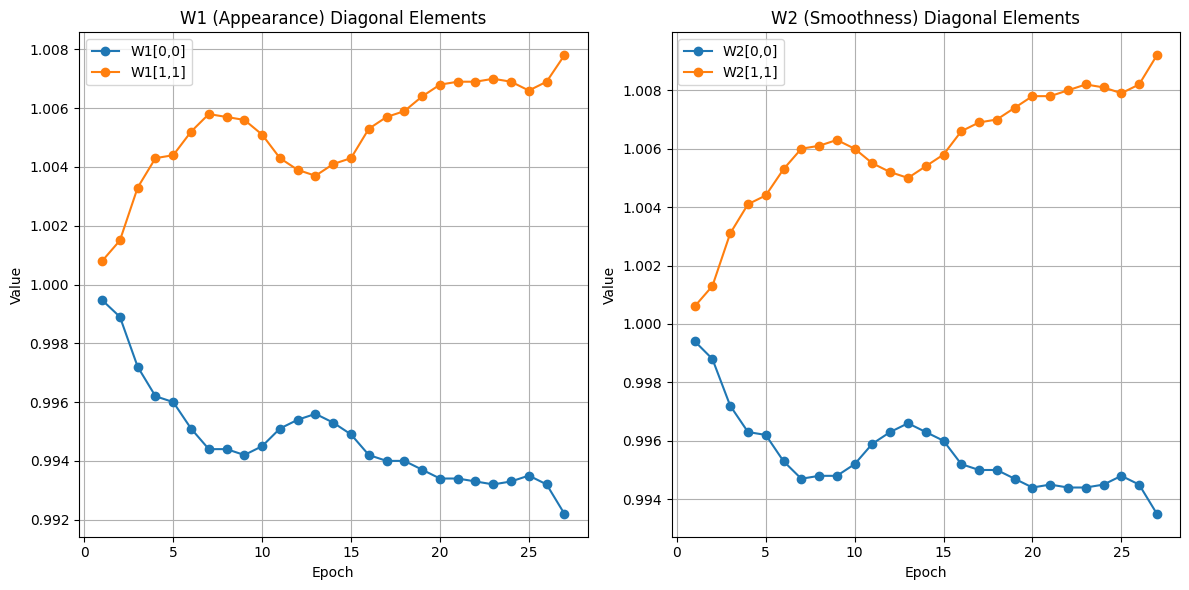

In [31]:
import re
import matplotlib.pyplot as plt

# ... (log_data string containing the log you provided) ...

epochs = []
w1_00 = []
w1_11 = []
w2_00 = []
w2_11 = []

lines = """
Epoch   1/100:
Training: 100%
 4/4 [00:06<00:00,  1.65s/it, Loss=0.1039]
Parameter Group 0, Learning Rate: 1e-05
Parameter Group 1, Learning Rate: 0.001
g""".split('\n')
current_epoch = None
expect_w2 = False
expect_w1 = False
w2_data = []
w1_data = []

i = 0
while i < len(lines):
    line = lines[i]

    # Check for Epoch header
    epoch_match = re.search(r'Epoch\s+(\d+)/100:', line)
    if epoch_match:
        current_epoch = int(epoch_match.group(1))

    # Check for W2 line
    if 'W2(Smoothness) Off_Diag_Mean' in line:
        expect_w2 = True
        i += 1
        continue

    # Check for W1 line
    if 'W1(Appearance) Off_Diag_Mean' in line:
        expect_w1 = True
        i += 1
        continue

    if expect_w2:
        if line.startswith('tensor'):
            # This line and next line contain the tensor
            # Line format: tensor([[ A, B],
            row1 = line
            row2 = lines[i+1]

            # Extract numbers
            nums1 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row1)
            nums2 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row2)

            if len(nums1) >= 1 and len(nums2) >= 2:
                w2_00_val = float(nums1[0])
                w2_11_val = float(nums2[1]) # The second number in second row is 1,1
                w2_data.append((current_epoch, w2_00_val, w2_11_val))

            expect_w2 = False
            i += 1 # Skip next line
            continue

    if expect_w1:
        if line.startswith('tensor'):
            row1 = line
            row2 = lines[i+1]

            nums1 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row1)
            nums2 = re.findall(r'[-+]?\d*\.\d+(?:[eE][-+]?\d+)?', row2)

            if len(nums1) >= 1 and len(nums2) >= 2:
                w1_00_val = float(nums1[0])
                w1_11_val = float(nums2[1])
                w1_data.append((current_epoch, w1_00_val, w1_11_val))

            expect_w1 = False
            i += 1
            continue

    i += 1

# Align data
plot_epochs = []
p_w1_00 = []
p_w1_11 = []
p_w2_00 = []
p_w2_11 = []

# w1_data and w2_data are lists of (epoch, val00, val11)
# Create a dictionary to merge
data_map = {}
for e, v00, v11 in w1_data:
    if e not in data_map: data_map[e] = {}
    data_map[e]['w1_00'] = v00
    data_map[e]['w1_11'] = v11

for e, v00, v11 in w2_data:
    if e not in data_map: data_map[e] = {}
    data_map[e]['w2_00'] = v00
    data_map[e]['w2_11'] = v11

sorted_epochs = sorted(data_map.keys())
for e in sorted_epochs:
    if 'w1_00' in data_map[e] and 'w2_00' in data_map[e]:
        plot_epochs.append(e)
        p_w1_00.append(data_map[e]['w1_00'])
        p_w1_11.append(data_map[e]['w1_11'])
        p_w2_00.append(data_map[e]['w2_00'])
        p_w2_11.append(data_map[e]['w2_11'])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(plot_epochs, p_w1_00, label='W1[0,0]', marker='o')
plt.plot(plot_epochs, p_w1_11, label='W1[1,1]', marker='o')
plt.title('W1 (Appearance) Diagonal Elements')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(plot_epochs, p_w2_00, label='W2[0,0]', marker='o')
plt.plot(plot_epochs, p_w2_11, label='W2[1,1]', marker='o')
plt.title('W2 (Smoothness) Diagonal Elements')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('diagonal_elements_plot.png')

In [54]:
import pandas as pd
tp = pd.DataFrame(data_map)
tp.loc[:,range(1,28,5)]

,1,6,11,16,21,26
w1_00,0.99947,0.9951,0.9951,0.9942,0.9934,0.9932
w1_11,1.00080,1.0052,1.0043,1.0053,1.0069,1.0069
w2_00,0.99941,0.9953,0.9959,0.9952,0.9945,0.9945
w2_11,1.00060,1.0053,1.0055,1.0066,1.0078,1.0082


In [ ]:
import pickle

trainer_result = {
    '_results': trainer._results,
    'best_epoch': trainer.best_epoch,
    'best_loss': trainer.best_loss,
    'train_loss': trainer.train_loss,
    'loss': trainer.loss,
}

with open(f'{RESULT_DIR}/trainer_result.pickle', 'wb') as f:
    pickle.dump(trainer_result, f)

In [ ]:
result_file_path = f'{RESULT_DIR}/trainer_result.pickle'

with open(result_file_path, 'rb') as file:
    trainer_result = pickle.load(file)

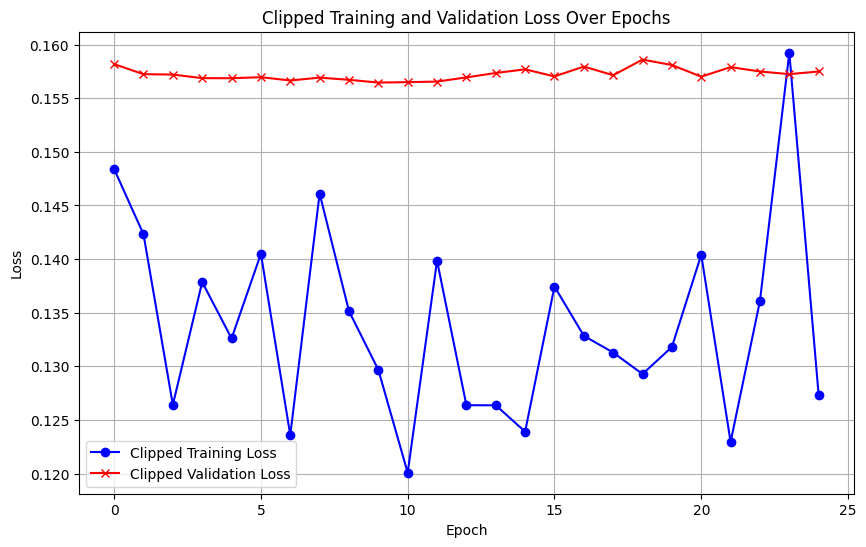

In [ ]:
import matplotlib.pyplot as plt

train_losses = trainer_result['train_loss']
val_losses = trainer_result['loss']  # Assuming 'loss' contains the validation losses

max_loss = 1  # Set a threshold for maximum loss to visualize

clipped_train_losses = [min(loss, max_loss) for loss in train_losses]
clipped_val_losses = [min(loss, max_loss) for loss in val_losses]

plt.figure(figsize=(10, 6))
plt.plot(clipped_train_losses, label='Clipped Training Loss', color='blue', marker='o')
plt.plot(clipped_val_losses, label='Clipped Validation Loss', color='red', marker='x')
plt.title('Clipped Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## ⭐ Evaluate

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

from torchvision.utils import save_image
from dataset import reconstruct_patched, collate_fn

def simple_micrograph_preprocessing(micrograph):
  micrograph_copy = micrograph.copy()
  micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
  micrograph_copy[micrograph_copy<0]=0
  micrograph_copy[micrograph_copy>1]=1
  return micrograph_copy

!mkdir {RESULT_DIR}/Each_ckpt

### ⏭ Test score for all saved checkpoint.

In [ ]:
# Check the last five best epochs
if not user:
    model = model_post
    checkpoint_paths = [path for path in os.listdir(RESULT_DIR) if '.pt' in path]
    for checkpoint_path in checkpoint_paths[-5:]:
        state_dict_path = f"{RESULT_DIR}/{checkpoint_path}"
        state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
        model.load_state_dict(state_dict, strict=False)
        model.eval()
        print("\nLoad model at: ", state_dict_path)
        #trainer = CryoEMTrainerWithScheduler(model, train_dataset, criterion, optimizer, device,
        #              num_classes=NUM_CLASSES,
        #              lr_scheduler=scheduler, patience=ES_PATIENCE)
        #result = trainer.evaluate(test_loader)
        model.to(DEVICE)
        model.eval()
        mini_batch_size = 9  # Number of patches to process at once
        with torch.no_grad():
            idx, (test_image, dnzd_test_image, _, grid, _) = next(enumerate(test_dataset))
            inputs = test_image.to(DEVICE)
            pairwise = dnzd_test_image.to(device) if (dnzd_test_image is not None) else None
            num_batches = (inputs.size(0) + mini_batch_size - 1) // mini_batch_size
            patched_outputs = []

            for batch_idx in range(num_batches):
                start_idx = batch_idx * mini_batch_size
                end_idx = min(start_idx + mini_batch_size, inputs.size(0))
                patch_input = inputs[start_idx:end_idx].to(DEVICE)
                patch_pairwise = pairwise[start_idx:end_idx].to(DEVICE) if (pairwise is not None) else None
                output = model(patch_input, patch_pairwise)['out']
                patched_outputs.append(output.cpu())  # Move to CPU to conserve GPU memory

                del patch_input
                torch.cuda.empty_cache()
            outputs = torch.cat(patched_outputs).to(DEVICE)  # Move to CPU to conserve GPU memory
            del patched_outputs
            torch.cuda.empty_cache()
            preds = outputs.argmax(dim=1).unsqueeze(1).cpu().detach()  # Now preds will have shape [81, 1, 512, 512]

            ## Plotting
            micrograph = np.load(f"{IMAGE_DIR}/val/{val_filenames[idx][:-4]}.npy")
            label_path = f"{LABEL_DIR}/{val_filenames[idx][:-4]}.png"


            micrograph_copy = simple_micrograph_preprocessing(micrograph)
            #crop_amount = 128  # Amount cropped from each side of the label image
            mic_width, mic_height = micrograph_copy.shape[1], micrograph_copy.shape[0]

            # Calculate starting and ending indices for cropping the micrograph
            #start_x = int((mic_width - 3840) / 2)
            #end_x = start_x + 3840
            #start_y = int((mic_height - 3840) / 2)
            #end_y = start_y + 3840

            # Crop the micrograph
            cropped_micrograph = micrograph_copy
            pred_image = reconstruct_patched(preds, grid).float()

            _,ax = plt.subplots(figsize=(12, 12))
            ax.imshow(cropped_micrograph, cmap='gray')
            ax.imshow(pred_image.squeeze(), cmap='inferno', alpha=0.4)
            plt.show()
            ##

            filename = f"{os.path.splitext(checkpoint_path)[0]}.png"
            pred_path = os.path.join(RESULT_DIR, "Each_ckpt", filename)
            save_image(pred_image, pred_path)

### ✅ Testing

In [ ]:
# @markdown do testing
model = model_post
# dir_name = "unet_eb5_dice_CRF" # @param {type:"string"}
CHECKPOINT_PATH = RESULT_DIR

dir_path = CHECKPOINT_PATH
import glob
search_pattern = os.path.join(dir_path, '*.pt')
list_of_files = glob.glob(search_pattern)
latest_file = max(list_of_files, key=os.path.getmtime)
print(f"Directory searched: {dir_path}")
print("-" * 30)
print(f"The **last modified checkpoint** file is:\n{latest_file}")


state_dict_path = latest_file
state_dict = torch.load(state_dict_path, map_location=torch.device(DEVICE))
model.load_state_dict(state_dict, strict=False)
model.to(DEVICE)
model.eval()
print("Load model at: ", state_dict_path)

Directory searched: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/weight_test_rst/10017/unet_eb5_dice_CRF
------------------------------
The **last modified checkpoint** file is:
/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/weight_test_rst/10017/unet_eb5_dice_CRF/checkpoint10.pt
Load model at:  /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/weight_test_rst/10017/unet_eb5_dice_CRF/checkpoint10.pt


In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    np.random.seed(24)
    selected_filenames = np.random.choice(test_filenames, size=6, replace=False)
    print(selected_filenames)
    test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=selected_filenames, crop_size=CROP_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True)

In [ ]:
evaluator = CryoEMEvaluator(
    model=model, device=DEVICE, metrics=['AP','iou'],
    num_classes=NUM_CLASSES)
print("ConvCRF validation result:")
result = evaluator.evaluate(loader=val_loader)
if not user:
    print("ConvCRF test result:")
    result = evaluator.evaluate(loader=test_loader)

ConvCRF validation result:
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
torch.Size([81, 1, 512, 512])
Iou by Class: [0.87576747 0.63161933]
Precision by Class: [0.9411229  0.75413775]
Recall by Class: [0.92653066 0.7954093 ]
Accuracy by Class: [0.897583 0.897583]
F1_score by Class: [0.93376976 0.7742239 ]


In [ ]:
# @markdown ---
# @markdown time used
end_time = time.time()
print(f"End time recorded: {end_time}")

elapsed_time = end_time - start_time
elapsed_time = elapsed_time


hours = int(elapsed_time // 3600)
remaining_seconds = elapsed_time % 3600

minutes = int(remaining_seconds // 60)
seconds = round(remaining_seconds % 60, 3)

print(f"Time spend : {hours} h, {minutes} m, {seconds} s")


gpu_used = "L4" # @param ["CPU high", "T4", "T4 high", "L4"]
per_unit_cost_dict = {"L4" : 1.71, "T4 high" : 1.41, "T4" : 1.19, "CPU high" :  0.24}
per_unit_cost = per_unit_cost_dict[gpu_used]
print(f"unit price per hr {per_unit_cost}")

cost_units = per_unit_cost * elapsed_time / 3600

per_unit_US = 10.49 / 100

cost_price_US = cost_units * per_unit_US

print(f"unit cost : {round(cost_units, 4)}")
print(f"unit price US: {cost_price_US}")
print(f"unit price NTD: {cost_price_US * 30.76}")

End time recorded: 1764660216.165862
Time spend : 0 h, 18 m, 33.205 s
unit price per hr 1.71
unit cost : 0.5288
unit price US: 0.055468218165844685
unit price NTD: 1.7062023907813826
